# \(B^\pm\to K^\pm K^\pm K^\mp\) — QMI S-wave direct-CP amplitude fit

This is the quasi-model-independent (QMI) variant of
[12_b2kkk_cpvfit.ipynb](12_b2kkk_cpvfit.ipynb). Data loading, background/efficiency
maps, the simultaneous-fit machinery, yield asymmetry, fit fractions and
goodness-of-fit are unchanged; only the coherent amplitude model differs.

## S-wave replacement

The isobar S-wave amplitudes of 12_b2kkk_cpvfit.ipynb --
`f0_980` (`BaBarFlatte`), `rescattering2` (`Rescattering2`), `f0_1500`,
`f0_1710` -- and the non-resonant `NR` amplitude are all removed and replaced
by a single quasi-model-independent S-wave, `S_QMI`: a `QMI` lineshape with
magnitude/phase free at each mass knot in \(m(K^+K^-)\), pair `(0,2)`,
covering the full kinematically accessible range from \(2m_K\) to
\(M_B-m_K\) (`NR` was not confined to a single pair, so `S_QMI` must span the
whole range it used to cover). `chi(c0)(1P)` is **not** absorbed into the QMI
binning -- it stays a separate, narrow spin-0 Breit-Wigner amplitude, exactly
as in 12_b2kkk_cpvfit.ipynb -- so the postfit S-wave shape can be compared
with and without its contribution (see "S-wave magnitude and phase" below).

Convention for `S_QMI`:

- **CP violation is global, not per knot**: `S_QMI` gets an ordinary free
  `CPRealImag(x, y, dx, dy)` coefficient, exactly like every other
  non-reference charmless component in this model -- the knot magnitudes and
  phases themselves are shared between B+ and B- and carry no separate CP
  parameters;
- **the first knot is fixed**: `S_QMI.mag_00` and `S_QMI.phase_00` are held
  at `(1, 0)` and not floated. Without this anchor, a global rescaling of all
  knot magnitudes together with the inverse rescaling of the `S_QMI`
  coefficient (and likewise a common phase shift of all knots against the
  coefficient phase) would leave the total amplitude unchanged -- an exact
  flat direction in the likelihood. Fixing one knot removes it, the same way
  `phi(1020)`'s `x`, `y` remove the overall scale/phase of the whole coherent
  sum;
- knots 1 and up start from a physically motivated seed: the old S-wave sum
  (`f0_980+rescattering2+f0_1500+f0_1710+NR`, BaBar starting values,
  CP-averaged) evaluated along the \(s_{13}=s_{23}\) diagonal -- the
  symmetry axis of the Dalitz plot for the two identical \(K^+\), which
  sweeps the full physical \(m(K^+K^-)\) range -- then rescaled so its value
  at knot 0 is exactly `(1, 0)`. See `build_models()` below.
- `phi(1020)` remains the model's single global CP/amplitude reference
  (unchanged from 12_b2kkk_cpvfit.ipynb).

## PDG-2026 masses and widths, via `particle`

Every real resonance is named after the exact string the `particle`
package resolves via `Particle.from_name` (e.g. `'rho(1450)0'`, not an
internal label like `'rho0_1450'`), and its nominal mass/width -- and, for
the four `GaussianConstraint`-anchored resonances, the constraint sigma
too -- comes directly from a `Particle` lookup (`pdg_mass_width()` in the
"BABAR Table-I model" section) rather than a hand-typed literal. The
notebook pins `particle`'s table to the 2026 PDG snapshot explicitly
(`Particle.load_table(...)`, in the imports cell) so results stay
reproducible even if a future `particle` release changes its own default
table. A transparency table right after `build_models()` lists the exact
mass/width used for every resonance, whether each is fixed or floating,
and its constraint sigma where one applies. `S_QMI`'s own declared
`mass=1.0, width=0.0` are unused classification placeholders, not `particle`-sourced.

## Other differences from 12_b2kkk_cpvfit.ipynb

- **No component normalization anywhere**: `normalize_components=False` for
  both the B+ and B- `DecayModel`s (12_b2kkk_cpvfit.ipynb used
  `normalize_components=True`). No component, including `S_QMI`, is rescaled
  to unit integral before its coefficient is applied.
- `rho(1450)0`/`rho(1700)0` keep their `GaussianConstraint`-anchored,
  optionally-floatable mass/width treatment unchanged (`FREE_RHO_1450_1700_MASS_WIDTH`),
  now joined by `phi(1020)` and `chi(c0)(1P)` (`FREE_PHI1020_MASS_WIDTH`/
  `FREE_CHIC0_MASS_WIDTH`).
- Everything else -- unfolded fit variables, `s31`->`s13` mapping, GeV²
  invariants, pair `(0,2)` for every resonance, the D0/J-psi veto, folded
  background/efficiency maps, the extended `YieldAsymmetry` yield treatment,
  and Minuit strategy 1 -- is identical to 12_b2kkk_cpvfit.ipynb.


In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"


# Já é o padrão; útil se essa opção estava desabilitada.
flags = os.environ.get("XLA_FLAGS", "")
os.environ["XLA_FLAGS"] = (
    flags + " --xla_cpu_multi_thread_eigen=true"
).strip()

os.environ["JAX_PLATFORMS"] = "cuda" # cpu, gpu, tpu

In [2]:

from dataclasses import dataclass, replace
from pathlib import Path
import inspect

from particle import Particle, data as particle_data

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    BaBarFlatte,
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DalitzAmplitude,
    GaussianConstraint,
    MassWindowVeto,
    QMI,
    DecayChannel,
    DecayModel,
    Parameter,
    PhaseSpaceMC,
    RealImag,
    Resonance,
    Rescattering2,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    YieldAsymmetry,
    GounarisSakurai,
    enable_x64,
    plot_pulls,
    read_phase_space_sample,
    read_root_tree,
)

enable_x64()

# Pin every Resonance mass/width sourced from the `particle` package below
# to the 2026 PDG snapshot explicitly, rather than relying on whatever table
# version happens to be `particle`'s own current default -- reproducible even
# if a future `particle` release changes that default.
Particle.load_table(particle_data.basepath / 'particle2026.csv', append=False)
print('particle tables:', Particle.table_names())

# Fail early if an older checkout is accidentally used.
_fit_signature = inspect.signature(CPFitSession.fit)
if not {'strategy', 'hesse', 'hessian'} <= _fit_signature.parameters.keys():
    raise RuntimeError(
        "This notebook requires the current DalitzPlotFitter main branch: "
        "CPFitSession.fit must expose strategy=, hesse= and hessian=."
    )


particle tables: ('/home/juan-leite/Work/DalitzPlotFitter/.venv/lib/python3.14/site-packages/particle/data/particle2026.csv',)


## Configuration

In [ ]:
ROOT_FILE = Path('/home/juan-leite/Work/data/B2KKK_data.root')
TREE_NAME = 'DecayTree'

MC_FILE = Path('/home/juan-leite/Work/data/mclarge151617_kkk.root')
MC_TREE_NAME = 'DecayTree'

BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    's12': 's12',
    's13': 's31',
    's23': 's23',
    # Already-folded Square-Dalitz coordinates (thPrime in [0, 0.5]).
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
}

MC_BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
    'pid_eff': 'Event_PIDCalibEff',
}

INVARIANT_UNIT = 'GeV2'

BPLUS_CHARGE_VALUE = +1
BMINUS_CHARGE_VALUE = -1

SIGNAL_MASS_WINDOW = (5230.0, 5330.0)
BKG_MASS_MIN = 5500.0

D0_MASS_GEV = 1.86484
D0_VETO_HALF_WIDTH_GEV = 0.060

# J/psi(1S) -> K+K- veto, same window convention as the D0 veto above
# (configurable half-width, applied to both opposite-sign K+K- pairings and
# both charges); the model itself no longer fits a Jpsi_1S component.
JPSI_MASS_GEV = 3.096900
JPSI_VETO_HALF_WIDTH_GEV = 0.030

def pdg_mass_width(particle_name):
    """Mass/width (GeV) and their PDG uncertainty (GeV), pinned to PDG
    2026 by the `Particle.load_table(...)` call above. `particle_name` must
    be the exact string the `particle` package resolves via
    `Particle.from_name` (e.g. 'rho(1450)0', not an internal component
    label like 'rho0_1450') -- this is also why every resonance below is
    named after its `particle`-recognized string directly.
    """
    particle = Particle.from_name(particle_name)
    mass_sigma = 0.5 * (particle.mass_lower + particle.mass_upper)
    width_sigma = 0.5 * (particle.width_lower + particle.width_upper)
    return dict(
        mass=particle.mass / 1000.0,
        mass_sigma=mass_sigma / 1000.0,
        width=particle.width / 1000.0,
        width_sigma=width_sigma / 1000.0,
    )


# rho(1450)0/rho(1700)0/phi(1020)/chi(c0)(1P) mass and width: PDG-2026
# central values and uncertainties (pdg_mass_width above), used both as
# the nominal Resonance mass/width and as the mean/sigma of a
# GaussianConstraint in build_models() below. Each FREE_*_MASS_WIDTH flag
# keeps that resonance's mass/width fixed at the PDG central value
# (default) or floats it, still penalized by the same Gaussian constraint
# around the PDG value either way.
FREE_RHO_1450_1700_MASS_WIDTH = False
FREE_PHI1020_MASS_WIDTH = False
FREE_CHIC0_MASS_WIDTH = False

RHO0_1450_PDG = pdg_mass_width('rho(1450)0')
RHO0_1700_PDG = pdg_mass_width('rho(1700)0')
PHI1020_PDG = pdg_mass_width('phi(1020)')
CHIC0_PDG = pdg_mass_width('chi(c0)(1P)')

# rho0(770)/f2'(1525)/phi(1680): PDG-2026 mass/width, not Gaussian-
# constrained (kept fixed, as plain floats, matching the previous
# hard-coded values) -- only their *source* changes here, from typed
# literals to a live particle lookup.
RHO0_770_PDG = pdg_mass_width('rho(770)0')
F2P_1525_PDG = pdg_mass_width("f(2)'(1525)")
PHI1680_PDG = pdg_mass_width('phi(1680)')

M_B_GEV = 5.27934
M_K_GEV = 0.493677
DAUGHTER_MASSES = (M_K_GEV, M_K_GEV, M_K_GEV)

# The two identical K+ are particles (0, 1) in ('K+', 'K+', 'K-'); this is
# the pair that must be used for the Square-Dalitz (m', theta') convention
# for `folded=True` to be valid (exchanging it leaves m' fixed and maps
# theta' -> 1 - theta'), and it matches the pair used to compute the ROOT
# files' own mPrime/thPrime branches (verified numerically against B_m).
# Used both for the goodness_of_fit_chi2(square_dalitz=True) postfit checks
# and for the folded background/efficiency Square-Dalitz histograms below.
SQDP_PAIR = (0, 1)

# toy-mc normalization: one shared flat phase-space sample (same masses for
# both charges) reused for both plus_model and minus_model, so integration
# noise does not differ between B+ and B- and bias the charge asymmetry.
NORMALIZATION_MC_SIZE = 1_000_000
NORMALIZATION_MC_SEED = 20260910

# (mPrime bins, thetaPrime-half bins): mPrime spans [0, 1], thetaPrime spans
# [0, 0.5] since the histograms are built directly from the already-folded
# ROOT mPrime/thPrime branches and evaluated with folded=True.
SEPARATE_BKG_BY_CHARGE = False
BACKGROUND_BINS = (45, 45)
BACKGROUND_SMOOTH_SIGMA = 1.0

USE_EFFICIENCY = True
EFFICIENCY_BINS = (45, 45)
EFFICIENCY_SMOOTH_SIGMA = 1.0

# Extended fit: N_signal, A_yield and N_combinatorial are known from an
# external measurement (e.g. an extended ML fit to the B mass spectrum) and
# are fixed (not floated) in this Dalitz fit -- only the amplitude
# parameters are free. YieldAsymmetry's raw counting asymmetry
# A_yield = (N_minus - N_plus) / N_s is independent of CPRealImag's
# coefficient-level A_CP (see docs/cp_coefficients.md).
SIGNAL_YIELD = 323_514  # TODO: set to the known N_signal
YIELD_ASYMMETRY = -0.037  # TODO: set to the known A_yield
BACKGROUND_YIELD =  11_826 + 30 # TODO: set to the known N_combinatorial

FIT_NSTARTS = 1
FIT_SEED = 20260903
FIT_TOLERANCE = 1e-4
FIT_VERBOSE = 3
FIT_STRATEGY = 1
# Automatic second derivatives also serve HESSE inside MIGRAD. The first
# call compiles a separate JAX program; subsequent calls reuse it.
# Requires iminuit >= 2.32. Use 'numerical' for the previous HESSE path.
FIT_HESSIAN = 'jax'

PROJECTION_SIZE = 2_000_000
PROJECTION_BINS = 100

# QMI S-wave knots in m(K+K-), pair (0,2): dense (~20 MeV) from the K+K-
# threshold up to 1.8 GeV to resolve f0(980)/rescattering2/f0(1500)/f0(1710),
# then sparse (~450 MeV) up to the kinematic upper edge M_B - m_K, which the
# S_QMI amplitude must cover in full since it also replaces the NR term that
# used to span the whole Dalitz plot. See build_models() below for how the
# knot values themselves are seeded.
QMI_THRESHOLD_GEV = 2.0 * M_K_GEV
QMI_UPPER_EDGE_GEV = M_B_GEV - M_K_GEV
QMI_DENSE_UPPER_GEV = 1.80
QMI_DENSE_STEP_GEV = 0.020
QMI_SPARSE_STEP_GEV = 0.45


def _build_qmi_knots():
    dense = np.arange(QMI_THRESHOLD_GEV, QMI_DENSE_UPPER_GEV, QMI_DENSE_STEP_GEV)
    sparse = np.arange(QMI_DENSE_UPPER_GEV, QMI_UPPER_EDGE_GEV, QMI_SPARSE_STEP_GEV)
    knots = np.concatenate([dense, sparse, [QMI_UPPER_EDGE_GEV]])
    return tuple(float(value) for value in np.unique(np.round(knots, 6)))


QMI_KNOTS_GEV = _build_qmi_knots()

# Configurable per the project's QMI interpolation modes (linear, cubic,
# hermite, natural); hermite is the default here since it stays smooth
# without cubic's flatten-then-bulge artifact between knots (docs/lineshapes.md).
QMI_INTERPOLATION = 'linear'  # 'linear', 'cubic', 'hermite', 'natural'


## Load unfolded signal data and folded sideband SqDP

In [4]:
def signal_cut(charge=None):
    lo, hi = SIGNAL_MASS_WINDOW
    cut = f"({BRANCH['mass']} >= {lo}) & ({BRANCH['mass']} <= {hi})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def sideband_cut(charge=None):
    cut = f"({BRANCH['mass']} > {BKG_MASS_MIN})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def convert_to_gev2(sample):
    if INVARIANT_UNIT == 'GeV2':
        return sample
    if INVARIANT_UNIT != 'MeV2':
        raise ValueError("INVARIANT_UNIT must be 'GeV2' or 'MeV2'")

    scale = 1e-6
    return PhaseSpaceSample(
        s12=jnp.asarray(sample.s12) * scale,
        s13=jnp.asarray(sample.s13) * scale,
        s23=jnp.asarray(sample.s23) * scale,
        weights=jnp.asarray(sample.weights),
        p1=sample.p1,
        p2=sample.p2,
        p3=sample.p3,
    )


def load_signal_sample(charge):
    sample = read_phase_space_sample(
        ROOT_FILE,
        TREE_NAME,
        s12=BRANCH['s12'],
        s13=BRANCH['s13'],
        s23=BRANCH['s23'],
        cut=signal_cut(charge),
    )
    return convert_to_gev2(sample)


def load_sideband_sqdp(charge):
    """Sideband events' already-folded (mPrime, thPrime), read directly."""
    return read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=sideband_cut(charge),
    )


def _mass_veto(mass_gev, half_width_gev):
    """CompositeVeto removing |m(KK) - mass_gev| <= half_width_gev in both
    opposite-sign K+K- pairings ((0,2) and (1,2))."""
    return CompositeVeto(
        MassWindowVeto((0, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
        MassWindowVeto((1, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
    )


D0_VETO = _mass_veto(D0_MASS_GEV, D0_VETO_HALF_WIDTH_GEV)
JPSI_VETO = _mass_veto(JPSI_MASS_GEV, JPSI_VETO_HALF_WIDTH_GEV)
CHARM_VETO = CompositeVeto(D0_VETO, JPSI_VETO)

_samples_before_veto = {
    'plus': load_signal_sample(BPLUS_CHARGE_VALUE),
    'minus': load_signal_sample(BMINUS_CHARGE_VALUE),
}
_samples_after_d0 = {
    charge: D0_VETO.apply(sample)
    for charge, sample in _samples_before_veto.items()
}
samples = {
    charge: JPSI_VETO.apply(sample)
    for charge, sample in _samples_after_d0.items()
}

for charge in ('plus', 'minus'):
    before = _samples_before_veto[charge].size
    after_d0 = _samples_after_d0[charge].size
    after_jpsi = samples[charge].size
    print(
        f"D0->KK veto   {charge:5s}: removed {before-after_d0:,} / {before:,} "
        f"events in |m(KK)-m(D0)| <= {1000.0*D0_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )
    print(
        f"J/psi->KK veto {charge:5s}: removed {after_d0-after_jpsi:,} / {after_d0:,} "
        f"events in |m(KK)-m(J/psi)| <= {1000.0*JPSI_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )


def load_signal_sqdp(charge_value, charge_key):
    """Signal-window (mPrime, thPrime), masked to match samples[charge_key]
    exactly: same signal_cut, then the same CHARM_VETO acceptance computed
    from the s13/s23 branches read alongside."""
    raw = read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            's13': BRANCH['s13'],
            's23': BRANCH['s23'],
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=signal_cut(charge_value),
    )
    mask = np.asarray(
        CHARM_VETO.accept({'s13': jnp.asarray(raw['s13']), 's23': jnp.asarray(raw['s23'])})
    )
    coords = {
        'mprime': np.asarray(raw['mprime'])[mask],
        'thetaprime': np.asarray(raw['thetaprime'])[mask],
    }
    if coords['mprime'].size != samples[charge_key].size:
        raise RuntimeError(
            f"{charge_key}: signal_sqdp size {coords['mprime'].size} != "
            f"samples size {samples[charge_key].size}"
        )
    return coords


signal_sqdp = {
    'plus': load_signal_sqdp(BPLUS_CHARGE_VALUE, 'plus'),
    'minus': load_signal_sqdp(BMINUS_CHARGE_VALUE, 'minus'),
}

bkg_sqdp = {
    'plus': load_sideband_sqdp(BPLUS_CHARGE_VALUE),
    'minus': load_sideband_sqdp(BMINUS_CHARGE_VALUE),
    'all': load_sideband_sqdp(None),
}

raw_control = read_root_tree(
    ROOT_FILE,
    TREE_NAME,
    {'mass': BRANCH['mass'], 'charge': BRANCH['charge']},
)
raw_control = {name: np.asarray(values) for name, values in raw_control.items()}

print(f"B+ signal events: {samples['plus'].size:,}")
print(f"B- signal events: {samples['minus'].size:,}")
print(f"ROOT candidates:  {len(raw_control['mass']):,}")
def mc_signal_cut(charge):
    """Use exactly the data signal-mass window and one B charge."""
    lo, hi = SIGNAL_MASS_WINDOW
    return (
        f"({MC_BRANCH['mass']} >= {lo}) & "
        f"({MC_BRANCH['mass']} <= {hi}) & "
        f"({MC_BRANCH['charge']} == {charge})"
    )


def load_efficiency_mc(charge):
    """Load the already-folded (mPrime, thPrime) and PID weight from MC."""
    return read_root_tree(
        MC_FILE,
        MC_TREE_NAME,
        {
            'mprime': MC_BRANCH['mprime'],
            'thetaprime': MC_BRANCH['thetaprime'],
            'pid_eff': MC_BRANCH['pid_eff'],
        },
        cut=mc_signal_cut(charge),
    )


def sanitize_efficiency_mc(coords, charge_label):
    """Remove entries that cannot contribute to a physical efficiency map."""
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)

    finite_mp = np.isfinite(mp)
    finite_tp = np.isfinite(tp)
    finite_pid = np.isfinite(pid_eff)

    valid = (
        finite_mp
        & finite_tp
        & finite_pid
        & (mp >= 0.0)
        & (mp <= 1.0)
        & (tp >= 0.0)
        & (tp <= 0.5)
        & (pid_eff > 0.0)
    )

    n_total = int(mp.size)
    n_valid = int(np.count_nonzero(valid))
    n_removed = n_total - n_valid

    print(f"\nEfficiency MC sanitation: {charge_label}")
    print(f"  total in mass/charge selection : {n_total:,}")
    print(f"  valid for efficiency map       : {n_valid:,}")
    print(
        f"  removed                        : {n_removed:,} "
        f"({100.0*n_removed/max(n_total,1):.5f}%)"
    )
    print(f"    non-finite mPrime             : {np.count_nonzero(~finite_mp):,}")
    print(f"    non-finite thPrime            : {np.count_nonzero(~finite_tp):,}")
    print(f"    non-finite Event_PIDCalibEff  : {np.count_nonzero(~finite_pid):,}")
    print(
        "    finite PID efficiency <= 0    : "
        f"{np.count_nonzero(finite_pid & (pid_eff <= 0.0)):,}"
    )

    if n_valid == 0:
        raise RuntimeError(f"{charge_label}: no valid efficiency-MC events")

    return {
        'mprime': jnp.asarray(mp[valid]),
        'thetaprime': jnp.asarray(tp[valid]),
        'pid_eff': jnp.asarray(pid_eff[valid]),
    }


efficiency_mc_raw = {
    'plus': load_efficiency_mc(BPLUS_CHARGE_VALUE),
    'minus': load_efficiency_mc(BMINUS_CHARGE_VALUE),
}

efficiency_mc = {
    'plus': sanitize_efficiency_mc(efficiency_mc_raw['plus'], 'B+'),
    'minus': sanitize_efficiency_mc(efficiency_mc_raw['minus'], 'B-'),
}

print(f"\nEfficiency MC retained B+: {len(efficiency_mc['plus']['mprime']):,}")
print(f"Efficiency MC retained B-: {len(efficiency_mc['minus']['mprime']):,}")

D0->KK veto   plus : removed 3,894 / 190,341 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto plus : removed 7,259 / 186,447 events in |m(KK)-m(J/psi)| <= 30 MeV
D0->KK veto   minus: removed 3,763 / 172,511 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto minus: removed 6,150 / 168,748 events in |m(KK)-m(J/psi)| <= 30 MeV
B+ signal events: 179,188
B- signal events: 162,598
ROOT candidates:  529,235

Efficiency MC sanitation: B+
  total in mass/charge selection : 1,287,105
  valid for efficiency map       : 1,286,803
  removed                        : 302 (0.02346%)
    non-finite mPrime             : 0
    non-finite thPrime            : 0
    non-finite Event_PIDCalibEff  : 0
    finite PID efficiency <= 0    : 302

Efficiency MC sanitation: B-
  total in mass/charge selection : 1,275,743
  valid for efficiency map       : 1,275,433
  removed                        : 310 (0.02430%)
    non-finite mPrime             : 0
    non-finite thPrime            : 1
    non-finite Event_PIDCali

In [5]:

def validate_inputs():
    for charge, sample in samples.items():
        for variable in ('s12', 's13', 's23'):
            values = np.asarray(getattr(sample, variable), dtype=float)
            if np.any(~np.isfinite(values)):
                raise RuntimeError(f"{charge}: non-finite {variable}")

        s13 = np.asarray(sample.s13, dtype=float)
        s23 = np.asarray(sample.s23, dtype=float)
        print(
            f"{charge:5s}: "
            f"s13=[{s13.min():.4f},{s13.max():.4f}] GeV^2, "
            f"s23=[{s23.min():.4f},{s23.max():.4f}] GeV^2, "
            f"fraction(s13>s23)={np.mean(s13 > s23):.3f}"
        )

    for charge, coords in signal_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if coords['mprime'].size != samples[charge].size:
            raise RuntimeError(f"{charge}: signal_sqdp size mismatch with samples")
        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"{charge}: non-finite mPrime/thPrime")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"{charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"{charge}: thPrime outside [0,0.5]")

        print(
            f"{charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    for charge, coords in bkg_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"BKG {charge}: non-finite SqDP coordinates")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"BKG {charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"BKG {charge}: thPrime outside [0,0.5]")

        print(
            f"BKG {charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    # Efficiency samples have already been sanitized; these are internal checks.
    for charge, coords in efficiency_mc.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)
        pid_eff = np.asarray(coords['pid_eff'], dtype=float)

        assert np.all(np.isfinite(mp))
        assert np.all(np.isfinite(tp))
        assert np.all(np.isfinite(pid_eff))
        assert np.all((0.0 <= mp) & (mp <= 1.0))
        assert np.all((0.0 <= tp) & (tp <= 0.5))
        assert np.all(pid_eff > 0.0)

        print(
            f"EFF {charge:5s}: N={len(mp):,}, "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}], "
            f"Event_PIDCalibEff=[{pid_eff.min():.6g},{pid_eff.max():.6g}]"
        )


validate_inputs()


plus : s13=[0.9749,23.3031] GeV^2, s23=[0.9749,23.3414] GeV^2, fraction(s13>s23)=0.500
minus: s13=[0.9750,23.3030] GeV^2, s23=[0.9750,23.2199] GeV^2, fraction(s13>s23)=0.499
plus : mPrime=[0.0092,1.0000], thPrime=[0.0001,0.5000]
minus: mPrime=[0.0157,0.9993], thPrime=[0.0001,0.5000]
BKG plus : mPrime=[0.0132,0.9993], thPrime=[0.0001,0.5000]
BKG minus: mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
BKG all  : mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
EFF plus : N=1,286,803, mPrime=[0.0013,0.9999], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0156231,5.66502]
EFF minus: N=1,275,433, mPrime=[0.0010,1.0000], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0159426,47.6501]


## Folded background/efficiency histograms and display-only Square-Dalitz coordinates

In [6]:

def smooth_histogram(values, sigma):
    values = np.asarray(values, dtype=float)
    if sigma is None or sigma <= 0:
        return values

    from scipy.ndimage import gaussian_filter
    return gaussian_filter(values, sigma=float(sigma), mode='nearest')


def build_background_map(coords, bins=BACKGROUND_BINS, sigma=BACKGROUND_SMOOTH_SIGMA):
    """Already-folded (mPrime, thPrime) sideband histogram -> smoothing ->
    SquareDalitzHistogramBackground(folded=True).

    thPrime in the ROOT files is already folded onto [0, 0.5] for the
    identical-K+ pair SQDP_PAIR, so the histogram is built directly on that
    half-domain; folded=True folds any query point onto it again at
    evaluation time (evaluated from the fit's own s12/s13/s23 via
    invariants_to_square_dalitz), so no explicit mirroring is needed.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    nx, ny = bins

    hist, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)),
    )

    hist = smooth_histogram(hist, sigma)
    hist = np.maximum(hist, 0.0)

    if not np.any(hist > 0.0):
        raise RuntimeError("Empty sideband histogram")

    model = SquareDalitzHistogramBackground(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(hist),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (hist, mp_edges, tp_edges)


def build_efficiency_map(coords, bins=EFFICIENCY_BINS, sigma=EFFICIENCY_SMOOTH_SIGMA):
    """PID-weighted already-folded (mPrime, thPrime) MC -> smoothing ->
    SquareDalitzHistogramEfficiency(folded=True).

    The histogram is the SUM of Event_PIDCalibEff weights per bin. No
    mean-by-bin and no independent per-charge rescaling are applied.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)
    nx, ny = bins

    weighted, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)), weights=pid_eff,
    )
    weighted = np.maximum(weighted, 0.0)

    if not np.any(weighted > 0.0):
        raise RuntimeError("Empty PID-weighted efficiency histogram")

    smoothed = smooth_histogram(weighted, sigma)
    smoothed = np.maximum(smoothed, 0.0)

    model = SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(smoothed),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (smoothed, mp_edges, tp_edges)


## BABAR Table-I model

In [7]:
# The isobar S-wave this notebook replaces with S_QMI (see the intro markdown
# above): kept here only to seed the QMI knots below with a physically
# motivated starting shape, not part of this notebook's fit model. Values are
# the same BaBar-derived starting points 12_b2kkk_cpvfit.ipynb uses for these
# components. (These internal labels are not renamed to match `particle`
# below -- they never feed a Resonance mass/width lookup, only this seed.)
_OLD_SWAVE_STARTS = {
    'f0_980': dict(rho=5.20, phase=0.48),
    'rescattering2': dict(rho=0.10, phase=0.00),
    'f0_1500': dict(rho=8.20, phase=1.29),
    'f0_1710': dict(rho=1.22, phase=-0.59),
    'NR': dict(rho=13.2, phase=0.00),
}
_OLD_NR_ALPHA = 0.152


def polar_to_xy(rho, phase):
    return float(rho * np.cos(phase)), float(rho * np.sin(phase))


@dataclass(frozen=True)
class BaBarExponentialNR:
    alpha: object

    def __call__(self, data):
        alpha = jnp.asarray(self.alpha)
        return (
            jnp.exp(-alpha * jnp.asarray(data['s13']))
            + jnp.exp(-alpha * jnp.asarray(data['s23']))
        ) / jnp.sqrt(2.0)


def _old_swave_reference_model():
    coefficient = {
        name: RealImag(*polar_to_xy(config['rho'], config['phase']))
        for name, config in _OLD_SWAVE_STARTS.items()
    }
    return DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        [
            Resonance(
                'f0_980',
                (0, 2),
                coefficient['f0_980'],
                lineshape=BaBarFlatte(),
                mass=0.965,
                width=0.0,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rescattering2',
                (0, 2),
                coefficient['rescattering2'],
                lineshape=Rescattering2(),
                mass=1.47,
                width=0.0,
                spin=0,
                resonance_radius=0.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_1500',
                (0, 2),
                coefficient['f0_1500'],
                mass=1.522,
                width=0.108,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'f0_1710',
                (0, 2),
                coefficient['f0_1710'],
                mass=1.715,
                width=0.125,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            DalitzAmplitude(
                'NR',
                dynamics=BaBarExponentialNR(_OLD_NR_ALPHA),
                coefficient=coefficient['NR'],
            ),
        ],
        normalize_components=False,
    )


def _old_swave_amplitude_on_diagonal(mass):
    """Old S-wave sum, evaluated at the symmetric Dalitz point s13=s23=mass**2.

    This diagonal is the symmetry axis of the Dalitz plot for the two
    identical K+ (pair (0,1)): it sweeps the full physical m(K+K-) range from
    threshold to M_B-m_K, so it is a valid Dalitz point at every QMI knot,
    including the two kinematic endpoints. Used only to seed the QMI knots
    below with a physically motivated starting shape -- the interpolation
    error and the fact that NR genuinely depends on both K+K- invariants (not
    just their common diagonal value) do not matter for a fit starting point.
    """
    mass = np.asarray(mass, dtype=float)
    s = mass**2
    s12 = M_B_GEV**2 + 3.0 * M_K_GEV**2 - 2.0 * s
    data = {
        's12': jnp.asarray(s12),
        's13': jnp.asarray(s),
        's23': jnp.asarray(s),
    }
    return np.asarray(_old_swave_reference_model().amplitude(data))


_qmi_seed_amplitude = _old_swave_amplitude_on_diagonal(np.asarray(QMI_KNOTS_GEV))
_qmi_seed_relative = _qmi_seed_amplitude / _qmi_seed_amplitude[0]
QMI_SEED_MAGNITUDES = np.abs(_qmi_seed_relative)
QMI_SEED_PHASES = np.unwrap(np.angle(_qmi_seed_relative))

# Resonance amplitudes are auto-symmetrized under the identical-K+ exchange
# (see the module docstring / CLAUDE.md), so evaluating on the s13=s23
# diagonal double-counts both identical pairings -- for every component here,
# uniformly in mass, so it cancels exactly in QMI_SEED_MAGNITUDES/_PHASES
# above (each is a ratio to the same knot-0 value). It does NOT cancel for
# the coefficient itself: S_QMI's own symmetrized dynamics at knot 0 already
# equal 2*(mag_00*exp(i*phase_00)) = 2 (mag_00, phase_00 are fixed to 1, 0),
# so the coefficient must be seeded at half the raw diagonal value for
# S_QMI.x/.y * dynamics(knot 0) to reproduce the old S-wave's true amplitude
# at knot 0.
_qmi_seed_coefficient = _qmi_seed_amplitude[0] / 2.0

print(f"QMI knots: {len(QMI_KNOTS_GEV)}")
print(
    "S_QMI coefficient seed (old S-wave sum at knot 0, halved for symmetrization): "
    f"rho={abs(_qmi_seed_coefficient):.4f}, phase={np.angle(_qmi_seed_coefficient):.4f} rad"
)


COEFFICIENT_STARTS = {
    # BaBar baseline starting values for the non-S-wave components, plus the
    # QMI S-wave's own seeded starting point. f0_980, rescattering2, f0_1500,
    # f0_1710 and NR from 12_b2kkk_cpvfit.ipynb are replaced by S_QMI;
    # chi(c0)(1P) stays a separate component (see the intro markdown above).
    # Every real resonance is keyed by its exact `particle`-recognized name
    # (see pdg_mass_width() above), so mass/width sourcing and this
    # coefficient dict use one consistent identifier per component.
    'phi(1020)': dict(rho=1.00, phase=0.0),
    'rho(770)0': dict(rho=0.10, phase=0.00),
    'rho(1450)0': dict(rho=0.10, phase=0.00),
    'rho(1700)0': dict(rho=0.10, phase=0.00),
    "f(2)'(1525)": dict(rho=0.10, phase=0.00),
    'phi(1680)': dict(rho=0.10, phase=0.00),
    'chi(c0)(1P)': dict(rho=0.437, phase=-1.02),
    'S_QMI': dict(
        rho=float(abs(_qmi_seed_coefficient)),
        phase=float(np.angle(_qmi_seed_coefficient)),
    ),
}


def make_cp_coefficients():
    result = {}

    for name, config in COEFFICIENT_STARTS.items():
        x0, y0 = polar_to_xy(config['rho'], config['phase'])
        is_reference = name == 'phi(1020)'

        # phi(1020) is the global reference: x, y fixed to remove the overall
        # amplitude scale/phase, dy fixed, only dx free (below). Every other
        # component -- including S_QMI and chi(c0)(1P) -- is a fully free
        # CPRealImag; for S_QMI this is the "global CPV" applied uniformly
        # to every knot (the knots themselves carry no separate CP
        # parameters).
        x = Parameter.coefficient(
            f'{name}.x',
            x0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )
        y = Parameter.coefficient(
            f'{name}.y',
            y0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )

        # Reference (phi(1020)) convention: dx free, dy fixed.
        dx = Parameter.coefficient(
            f'{name}.dx',
            0.0,
            owner=name,
            fixed=False,
            step=0.005,
        )
        dy = Parameter.coefficient(
            f'{name}.dy',
            0.0,
            owner=name,
            fixed=is_reference,
            step=0.005,
        )

        result[name] = CPRealImag(x, y, dx, dy)

    return result


def build_models():
    shared = make_cp_coefficients()

    # rho(1450)0/rho(1700)0 mass and width as fittable dynamics parameters
    # (shared across both charges, like nr_alpha in 12_b2kkk_cpvfit.ipynb)
    # rather than plain floats, so a GaussianConstraint can pin them to their
    # PDG-2026 central values (pdg_mass_width() above).
    # FREE_RHO_1450_1700_MASS_WIDTH toggles fixed vs. floating; the Gaussian
    # penalty around the PDG value applies either way (see build_session()).
    rho0_1450_mass = Parameter.dynamics(
        'rho(1450)0.mass',
        RHO0_1450_PDG['mass'],
        owner='rho(1450)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(1.30, 1.60),
        step=0.005,
    )
    rho0_1450_width = Parameter.dynamics(
        'rho(1450)0.width',
        RHO0_1450_PDG['width'],
        owner='rho(1450)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(0.10, 0.70),
        step=0.010,
    )
    rho0_1700_mass = Parameter.dynamics(
        'rho(1700)0.mass',
        RHO0_1700_PDG['mass'],
        owner='rho(1700)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(1.55, 1.90),
        step=0.005,
    )
    rho0_1700_width = Parameter.dynamics(
        'rho(1700)0.width',
        RHO0_1700_PDG['width'],
        owner='rho(1700)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(0.05, 0.50),
        step=0.010,
    )
    # phi(1020)/chi(c0)(1P) mass and width, same fixed-with-optional-float
    # convention as rho(1450)0/rho(1700)0 above (FREE_PHI1020_MASS_WIDTH /
    # FREE_CHIC0_MASS_WIDTH).
    phi1020_mass = Parameter.dynamics(
        'phi(1020).mass',
        PHI1020_PDG['mass'],
        owner='phi(1020)',
        fixed=not FREE_PHI1020_MASS_WIDTH,
        bounds=(0.99, 1.05),
        step=0.0005,
    )
    phi1020_width = Parameter.dynamics(
        'phi(1020).width',
        PHI1020_PDG['width'],
        owner='phi(1020)',
        fixed=not FREE_PHI1020_MASS_WIDTH,
        bounds=(0.001, 0.010),
        step=0.0002,
    )
    chic0_mass = Parameter.dynamics(
        'chi(c0)(1P).mass',
        CHIC0_PDG['mass'],
        owner='chi(c0)(1P)',
        fixed=not FREE_CHIC0_MASS_WIDTH,
        bounds=(3.38, 3.45),
        step=0.0005,
    )
    chic0_width = Parameter.dynamics(
        'chi(c0)(1P).width',
        CHIC0_PDG['width'],
        owner='chi(c0)(1P)',
        fixed=not FREE_CHIC0_MASS_WIDTH,
        bounds=(0.001, 0.030),
        step=0.0005,
    )

    mass_width_constraints = (
        GaussianConstraint(rho0_1450_mass, mean=RHO0_1450_PDG['mass'], sigma=RHO0_1450_PDG['mass_sigma']),
        GaussianConstraint(rho0_1450_width, mean=RHO0_1450_PDG['width'], sigma=RHO0_1450_PDG['width_sigma']),
        GaussianConstraint(rho0_1700_mass, mean=RHO0_1700_PDG['mass'], sigma=RHO0_1700_PDG['mass_sigma']),
        GaussianConstraint(rho0_1700_width, mean=RHO0_1700_PDG['width'], sigma=RHO0_1700_PDG['width_sigma']),
        GaussianConstraint(phi1020_mass, mean=PHI1020_PDG['mass'], sigma=PHI1020_PDG['mass_sigma']),
        GaussianConstraint(phi1020_width, mean=PHI1020_PDG['width'], sigma=PHI1020_PDG['width_sigma']),
        GaussianConstraint(chic0_mass, mean=CHIC0_PDG['mass'], sigma=CHIC0_PDG['mass_sigma']),
        GaussianConstraint(chic0_width, mean=CHIC0_PDG['width'], sigma=CHIC0_PDG['width_sigma']),
    )

    # S_QMI knots: knot 0 fixed at (1, 0) as the anchor described in the
    # intro markdown above; every other knot floats, starting from the old
    # S-wave sum's shape relative to knot 0 (QMI_SEED_MAGNITUDES/_PHASES).
    qmi_magnitudes = tuple(
        Parameter.dynamics(
            f'S_QMI.mag_{i:02d}',
            float(value),
            owner='S_QMI',
            fixed=(i == 0),
            bounds=(0.0, None),
            step=max(0.01, 0.02 * float(value)),
        )
        for i, value in enumerate(QMI_SEED_MAGNITUDES)
    )
    qmi_phases = tuple(
        Parameter.dynamics(
            f'S_QMI.phase_{i:02d}',
            float(value),
            owner='S_QMI',
            fixed=(i == 0),
            step=0.02,
        )
        for i, value in enumerate(QMI_SEED_PHASES)
    )
    s_qmi_lineshape = QMI(
        knots=QMI_KNOTS_GEV,
        magnitudes=qmi_magnitudes,
        phases=qmi_phases,
        interpolation=QMI_INTERPOLATION,
    )

    def components(charge):
        coefficient = {
            name: cp_coefficient.for_charge(charge)
            for name, cp_coefficient in shared.items()
        }

        return [
            Resonance(
                'phi(1020)',
                (0, 2),
                coefficient['phi(1020)'],
                mass=phi1020_mass,
                width=phi1020_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(770)0',
                (0, 2),
                coefficient['rho(770)0'],
                mass=RHO0_770_PDG['mass'],
                width=RHO0_770_PDG['width'],
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(1450)0',
                (0, 2),
                coefficient['rho(1450)0'],
                mass=rho0_1450_mass,
                width=rho0_1450_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(1700)0',
                (0, 2),
                coefficient['rho(1700)0'],
                mass=rho0_1700_mass,
                width=rho0_1700_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'S_QMI',
                (0, 2),
                coefficient['S_QMI'],
                lineshape=s_qmi_lineshape,
                mass=1.0,
                width=0.0,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                "f(2)'(1525)",
                (0, 2),
                coefficient["f(2)'(1525)"],
                mass=F2P_1525_PDG['mass'],
                width=F2P_1525_PDG['width'],
                spin=2,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'phi(1680)',
                (0, 2),
                coefficient['phi(1680)'],
                mass=PHI1680_PDG['mass'],
                width=PHI1680_PDG['width'],
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'chi(c0)(1P)',
                (0, 2),
                coefficient['chi(c0)(1P)'],
                mass=chic0_mass,
                width=chic0_width,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
        ]

    # toy-mc normalization: one flat 1M-event PhaseSpaceMC sample, generated
    # once and reused unchanged for both plus/minus DecayModel instances
    # (same mother/daughter masses for B+ and B-), auto-selecting
    # normalization_method='toy-mc'. No new integration points are drawn
    # during minimization (docs/mc_integration.md).
    #
    # PhaseSpaceMC.generate() weights carry its own proposal measure
    # (ds12 ds13 / (128*pi**3*M**2)); the deterministic grid this replaces
    # integrates in plain ds12 ds13. Rescaling by 128*pi**3*M**2 keeps the
    # same measure so the fitted density and NLL stay on the same absolute
    # scale as the previous gauss-legendre normalization (verified
    # numerically: without this factor the NLL at the BaBar starting values
    # differs by the corresponding huge constant, ~exp(11.6) per event).
    raw_normalization_mc = PhaseSpaceMC(M_B_GEV, DAUGHTER_MASSES).generate(
        NORMALIZATION_MC_SIZE,
        seed=NORMALIZATION_MC_SEED,
        include_momenta=False,
    )
    measure_factor = 128.0 * np.pi**3 * M_B_GEV**2
    normalization_mc = replace(
        raw_normalization_mc,
        weights=raw_normalization_mc.weights * measure_factor,
    )

    normalization_options = dict(
        normalization_method="gauss-legendre",
        normalization_bin_width=0.005,
        normalization_narrow_width=0.020,
        normalization_narrow_window=5.0,
        normalization_binning_factor=20.0,
        normalization_chunk_size=50_000,
    )

    plus = DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        components(+1),
        normalize_components=False,
        **normalization_options,
        #normalization_sample=normalization_mc,
    )

    minus = DecayModel(
        DecayChannel('B-', ('K-', 'K-', 'K+')),
        components(-1),
        normalize_components=False,
        **normalization_options,
        #normalization_sample=normalization_mc,
    )

    return plus, minus, shared, mass_width_constraints


plus_model, minus_model, shared_coefficients, mass_width_constraints = build_models()

print("normalization_method =", plus_model.normalization_method)
print("B+ normalization points =", plus_model.normalization_sample.size)
print("B- normalization points =", minus_model.normalization_sample.size)


QMI knots: 49
S_QMI coefficient seed (old S-wave sum at knot 0, halved for symmetrization): rho=35.9856, phase=1.7309 rad
normalization_method = gauss-legendre
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019460 GeV, Gamma=4.249 MeV; m13: m0=3.415500 GeV, Gamma=12.400 MeV; m23: m0=1.019460 GeV, Gamma=4.249 MeV; m23: m0=3.415500 GeV, Gamma=12.400 MeV); using adaptive Gauss-Legendre normalization.
B+ normalization points = 749331
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019460 GeV, Gamma=4.249 MeV; m13: m0=3.415500 GeV, Gamma=12.400 MeV; m23: m0=1.019460 GeV, Gamma=4.249 MeV; m23: m0=3.415500 GeV, Gamma=12.400 MeV); using adaptive Gauss-Legendre normalization.
B- normalization points = 749331


### Resonance masses and widths used

Transparency table for every real resonance (`S_QMI` excluded -- its declared `mass=1.0, width=0.0` are unused placeholders, see `build_models()` above): the exact mass/width value entering the fit, whether it is fixed or floating, and the `GaussianConstraint` sigma anchoring it where one exists. All PDG-sourced values come from the 2026 snapshot pinned at the top of this notebook.

In [8]:
def _resolve_scalar(value):
    return float(value.value) if isinstance(value, Parameter) else float(value)


def _is_fixed(value):
    return bool(value.fixed) if isinstance(value, Parameter) else True


_constraint_by_parameter = {
    constraint.parameter.name: constraint for constraint in mass_width_constraints
}


def _constraint_sigma(value):
    if not isinstance(value, Parameter):
        return np.nan
    constraint = _constraint_by_parameter.get(value.name)
    return float(constraint.sigma) if constraint is not None else np.nan


mass_width_rows = [
    dict(
        component=component.name,
        mass_GeV=_resolve_scalar(component.mass),
        mass_fixed=_is_fixed(component.mass),
        mass_constraint_sigma_GeV=_constraint_sigma(component.mass),
        width_GeV=_resolve_scalar(component.width),
        width_fixed=_is_fixed(component.width),
        width_constraint_sigma_GeV=_constraint_sigma(component.width),
    )
    for component in plus_model.components
    if isinstance(component, Resonance) and component.name != 'S_QMI'
]

mass_width_table = pd.DataFrame(mass_width_rows)
display(mass_width_table)


,component,mass_GeV,mass_fixed,mass_constraint_sigma_GeV,width_GeV,width_fixed,width_constraint_sigma_GeV
0,phi(1020),1.01946,True,0.000016,0.004249,True,0.000013
1,rho(770)0,0.77526,True,NaN,0.147400,True,NaN
2,rho(1450)0,1.46500,True,0.025000,0.400000,True,0.060000
3,rho(1700)0,1.72000,True,0.020000,0.250000,True,0.100000
4,f(2)'(1525),1.51730,True,NaN,0.072000,True,NaN
5,phi(1680),1.68000,True,NaN,0.150000,True,NaN
6,chi(c0)(1P),3.41550,True,0.000190,0.012400,True,0.000270


### \(\phi(1680)\)

The model keeps the existing \(f_0(1710)\) amplitude and now also includes
\(\phi(1680)\to K^+K^-\) as a spin-1 Breit-Wigner in `pair=(0,2)`, with fixed
nominal mass and width

\[
m_{\phi(1680)}=1.680~\mathrm{GeV},\qquad
\Gamma_{\phi(1680)}=0.150~\mathrm{GeV}.
\]

Its CP-even and CP-odd coefficient parameters are free, like the other
charmless amplitudes. The initial coefficient magnitude is 0.10 with phase 0.

### CP convention for charmonium

\(\chi_{c0}\) is a fully free `CPRealImag` component (\(x,y,dx,dy\) all float), the same as every other non-reference charmless amplitude in this model.

`phi(1020)` is the global CP reference: its \(x,y\) and \(dy\) are fixed, only \(dx\) floats, removing the overall amplitude scale/phase of the whole coherent sum.

### QMI S-wave and charm veto

The isobar S-wave of 12_b2kkk_cpvfit.ipynb (`f0_980`, `rescattering2`, `f0_1500`, `f0_1710`, `NR`) is replaced here by one quasi-model-independent amplitude, `S_QMI` -- see the intro markdown at the top of this notebook for the knot binning, the first-knot anchor and the seeding of the starting values. `S_QMI`'s complex CP coefficient is free for the B+ and B- simultaneous fit, using the same `CPRealImag` convention as every other charmless amplitude; `chi(c0)(1P)` remains a separate, narrow spin-0 Breit-Wigner rather than being folded into the QMI binning.

A `CompositeVeto` made from two `MassWindowVeto` objects removes

\[
|m(K^+K^-)-m_{D^0}| \le 60\,\mathrm{MeV}
\]

for both opposite-sign pairings, and a second `CompositeVeto` removes

\[
|m(K^+K^-)-m_{J/\psi}| \le 30\,\mathrm{MeV}
\]

(both half-widths configurable via `D0_VETO_HALF_WIDTH_GEV` /
`JPSI_VETO_HALF_WIDTH_GEV`). The two are combined into one `CHARM_VETO`. The
model does not fit an explicit `Jpsi_1S` component -- that mass region is
excised by the veto instead. The same combined veto is applied to the
selected data and to the fit session, so signal normalization, combinatorial
background and fit projections all use the same accepted Dalitz region. The
QMI knots continue smoothly through both vetoed windows -- they are
unconstrained by data there, same as any other interpolated region between
knots, and are stabilized by the rest of the coherent fit instead.

## Simultaneous fit session

In [9]:

def build_session():
    if SEPARATE_BKG_BY_CHARGE:
        plus_background, _ = build_background_map(bkg_sqdp['plus'])
        minus_background, _ = build_background_map(bkg_sqdp['minus'])
    else:
        common_background, _ = build_background_map(bkg_sqdp['all'])
        plus_background = common_background
        minus_background = common_background

    # N_signal, A_yield and N_combinatorial are known (fixed) rather than
    # fit here -- only the amplitude parameters float.
    signal_yield = YieldAsymmetry(
        Parameter(
            'n_signal',
            SIGNAL_YIELD,
            fixed=True,
        ),
        Parameter(
            'a_cp_yield',
            YIELD_ASYMMETRY,
            fixed=True,
        ),
    )

    fit_session = CPFitSession(
        plus_model,
        minus_model,
        samples['plus'],
        samples['minus'],
        extended=True,
        signal_yield=signal_yield,
    )

    if USE_EFFICIENCY:
        plus_efficiency, _ = build_efficiency_map(efficiency_mc['plus'])
        minus_efficiency, _ = build_efficiency_map(efficiency_mc['minus'])
        fit_session = fit_session.with_efficiency(
            plus_efficiency,
            minus_efficiency,
        )

    fit_session = fit_session.with_veto(CHARM_VETO)

    fit_session = fit_session.with_background(
        'combinatorial',
        plus_background,
        minus_shape=minus_background,
        yield_=Parameter(
            'n_combinatorial',
            BACKGROUND_YIELD,
            fixed=True,
        ),
    )

    # rho(1450)0/rho(1700)0, phi(1020) and chi(c0)(1P) mass/width all stay
    # Gaussian-constrained to their PDG values whether they are fixed or
    # floated (see FREE_RHO_1450_1700_MASS_WIDTH / FREE_PHI1020_MASS_WIDTH /
    # FREE_CHIC0_MASS_WIDTH above).
    for constraint in mass_width_constraints:
        fit_session = fit_session.with_constraint(constraint)

    return fit_session


session = build_session()

for parameter in session.parameters:
    print(
        f"{parameter.name:24s} "
        f"value={parameter.value: .6g} fixed={parameter.fixed}"
    )


phi(1020).x              value= 1 fixed=True
phi(1020).y              value= 0 fixed=True
phi(1020).dx             value= 0 fixed=False
phi(1020).dy             value= 0 fixed=True
phi(1020).mass           value= 1.01946 fixed=True
phi(1020).width          value= 0.004249 fixed=True
rho(770)0.x              value= 0.1 fixed=False
rho(770)0.y              value= 0 fixed=False
rho(770)0.dx             value= 0 fixed=False
rho(770)0.dy             value= 0 fixed=False
rho(1450)0.x             value= 0.1 fixed=False
rho(1450)0.y             value= 0 fixed=False
rho(1450)0.dx            value= 0 fixed=False
rho(1450)0.dy            value= 0 fixed=False
rho(1450)0.mass          value= 1.465 fixed=True
rho(1450)0.width         value= 0.4 fixed=True
rho(1700)0.x             value= 0.1 fixed=False
rho(1700)0.y             value= 0 fixed=False
rho(1700)0.dx            value= 0 fixed=False
rho(1700)0.dy            value= 0 fixed=False
rho(1700)0.mass          value= 1.72 fixed=True
rho(1700)0.wid

## Prefit and postfit helpers

In [10]:
def plot_all_diagnostics(fit_result, title_prefix, seed):
    """Folded s_low/s_high projections via `session.plot_projection`
    (data, per-component curves, total fit and pulls) -- the one postfit
    visual `CPFitSession` already implements as a single call, for both
    charges and with a shared-x-axis pull panel included.

    The quantitative 2D diagnostics (plain Dalitz, Square-Dalitz) and the
    unbinned PPD test are *not* reimplemented here a second time: they live
    in the "Goodness of fit" section below via `goodness_of_fit_chi2`/
    `plot_pulls`/`point_to_point_dissimilarity`, which is the actual
    session-level API for them. Earlier revisions of this notebook hand-rolled
    all of this (custom 1D mass-unit projections, custom Square-Dalitz 1D
    projections reading the ROOT files' own mPrime/thPrime branches, and
    custom 2D data/model/pull triptychs); those pieces are dropped rather
    than kept as one-off duplicates of what the fitter now provides directly.
    """
    for fold_side in ('low', 'high'):
        session.plot_projection(
            fit_result, 's13', partner_variable='s23',
            folded=True, fold_side=fold_side,
            bins=PROJECTION_BINS, projection_size=PROJECTION_SIZE,
            projection_seed=seed, show_pulls=True,
        )
        plt.show()

    # Zoomed s_low (< 4 GeV^2): the same projection restricted to where the
    # QMI S-wave structure (threshold cusp, f0(1500)/f0(1710) region) sits,
    # since the full s13 in [~1, ~23] GeV^2 range above compresses it.
    print(f"{title_prefix}: s_low zoom below 4 GeV^2")
    session.plot_projection(
        fit_result, 's13', partner_variable='s23',
        folded=True, fold_side='low', range=(QMI_THRESHOLD_GEV**2, 1.1),
        bins=PROJECTION_BINS, projection_size=PROJECTION_SIZE,
        projection_seed=seed, show_pulls=True,
    )
    plt.show()


## Fit with Minuit strategy 1

`FIT_HESSIAN="jax"` supplies automatic second derivatives for the 125-parameter
QMI/CP fit, including internal HESSE calls during MIGRAD. The first Hessian
evaluation includes JAX compilation. `FIT_VERBOSE >= 1` prints elapsed time and
function/gradient counts per optimizer stage. Keep `hesse=True` for the final
covariance; `hesse=False` would skip only the final explicit call.

The saved output below records the earlier numerical-Hessian run. Rerun the
fit after reloading the updated library to evaluate the new setting.


In [11]:

if FIT_NSTARTS == 1:
    result = session.fit(
        simplex=False,
        strategy=FIT_STRATEGY,
        hessian=FIT_HESSIAN,
        hesse=True,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    scan_results = (result,)
else:
    multistart = session.fit_multistart(
        n_starts=FIT_NSTARTS,
        seed=FIT_SEED,
        include_default=True,
        simplex=False,
        strategy=FIT_STRATEGY,
        hessian=FIT_HESSIAN,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    result = multistart.best
    scan_results = multistart.results

fit_report = session.report(
    result,
    include_fit_fractions=False,
    include_correlation=True,
)


[Minimizer] single fit with 125 free parameters (simplex=False, strategy=1, hesse=True, hessian=jax, ncall=None, tolerance=0.0001)
[Minimizer] MIGRAD 1 started
I MnSeedGenerator Computing seed using analytical (external) gradients and Hessian calculator
I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 24.7943 s
I MnSeedGenerator Initial seeding state  
  Minimum value : -2035930.025
  Edm           : 435422.3704
  Internal parameters:	[                0       4.21332561                0                0                0              0.1                0                0                0              0.1....                 0]	
  Internal gradient  :	[      2107.907779     -2355.697529     -7602.130786     -624.1880566      935.1394625      846.2828057     -4957.279294     -30.73555843     -964.6916973     -12774.38741....       115.7930237]	
  Internal covariance matrix:
[[  1.5408775e-05              0     

## Yield asymmetry

In [12]:
postfit_yield_values = session.result_values(result)

expected_total = float(session.base_objective.expected_events(postfit_yield_values))
n_signal_total = float(session.signal_yield.total.resolve(postfit_yield_values))
a_cp_yield = float(session.signal_yield.asymmetry.resolve(postfit_yield_values))
n_signal_plus = float(session.signal_yield.plus(postfit_yield_values))
n_signal_minus = float(session.signal_yield.minus(postfit_yield_values))

print(f"expected total events (signal + background): {expected_total:.2f}")
print(f"N_signal (total)  = {n_signal_total:.2f}")
print(f"A_yield           = {a_cp_yield:.4f}")
print(f"N_signal(B+)      = {n_signal_plus:.2f}")
print(f"N_signal(B-)      = {n_signal_minus:.2f}")

expected total events (signal + background): 335370.00
N_signal (total)  = 323514.00
A_yield           = -0.0370
N_signal(B+)      = 167742.01
N_signal(B-)      = 155771.99


## Fit fractions

Central values plus delta-method standard errors (exact `jax.jacrev` Jacobian of `PreparedAmplitudeCache.fit_fractions` through the postfit covariance -- see `docs/fitting.md` "Fit fraction errors (delta method)" for the full derivation, the joint-covariance treatment of `FF_mean`, and a documented pitfall in propagating a Minuit covariance by shape instead of by parameter name).

In [13]:
fit_fractions = session.print_fit_fractions(
    result,
    acceptance_weighted=USE_EFFICIENCY,
    include_interference=False,
    precision=4,
)

# Delta-method standard errors (exact autodiff Jacobian x postfit covariance,
# see docs/fitting.md "Fit fraction errors"). fit_fraction_errors propagates
# the *joint* B+/B- covariance in one Jacobian rather than two independent
# ones, since almost every fit parameter here (every QMI knot, every
# CPRealImag coefficient) is shared between the two charges -- that shared
# covariance is what makes 'mean' below more than a naive quadrature sum.
fit_fraction_errors = session.fit_fraction_errors(
    result, acceptance_weighted=USE_EFFICIENCY,
)

plus_ff = fit_fractions['plus']
minus_ff = fit_fractions['minus']

component_names = [
    name for name in plus_ff
    if name in minus_ff
]

ff_table = pd.DataFrame({
    'component': component_names,
    'FF_plus': [float(plus_ff[name]) for name in component_names],
    'sigma(FF_plus)': [fit_fraction_errors['plus'][name] for name in component_names],
    'FF_minus': [float(minus_ff[name]) for name in component_names],
    'sigma(FF_minus)': [fit_fraction_errors['minus'][name] for name in component_names],
})

ff_table['FF_mean'] = 0.5 * (
    ff_table['FF_plus'] + ff_table['FF_minus']
)
ff_table['sigma(FF_mean)'] = [
    fit_fraction_errors['mean'][name] for name in component_names
]

display(ff_table)

B+ fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi(1020)                         12.6140
rho(770)0                          0.5120
rho(1450)0                         8.6979
rho(1700)0                        17.4708
S_QMI                             77.3459
f(2)'(1525)                        0.1519
phi(1680)                          7.2943
chi(c0)(1P)                        6.0261
sum                              130.1129

B- fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi(1020)                         14.1671
rho(770)0                          0.4923
rho(1450)0                         8.8627
rho(1700)0                        32.6903
S_QMI                             76.3253
f(2)'(1525)                        0.4593
phi(1680)                         11.3698
chi(c0)(1P)                        6.0447
sum                              150.4113


,component,FF_plus,sigma(FF_plus),FF_minus,sigma(FF_minus),FF_mean,sigma(FF_mean)
0,phi(1020),0.126140,0.000983,0.141671,0.001038,0.133905,0.000758
1,rho(770)0,0.005120,0.000615,0.004923,0.001017,0.005022,0.000641
2,rho(1450)0,0.086979,0.004345,0.088627,0.004156,0.087803,0.003730
3,rho(1700)0,0.174708,0.009490,0.326903,0.015053,0.250805,0.009920
4,S_QMI,0.773459,0.002515,0.763253,0.002817,0.768356,0.002295
5,f(2)'(1525),0.001519,0.000159,0.004593,0.000300,0.003056,0.000186
6,phi(1680),0.072943,0.004858,0.113698,0.006989,0.093320,0.004734
7,chi(c0)(1P),0.060261,0.000781,0.060447,0.000796,0.060354,0.000574


## CP coefficients

In [14]:
def _cp_observables(theta):
    x, y, dx, dy = theta
    c_plus = complex(x + dx, y + dy)
    c_minus = complex(x - dx, y - dy)
    mag_plus = abs(c_plus)
    mag_minus = abs(c_minus)
    phase_plus = np.angle(c_plus)
    phase_minus = np.angle(c_minus)
    denominator = mag_minus**2 + mag_plus**2
    acp = (mag_minus**2 - mag_plus**2) / denominator if denominator > 0.0 else np.nan
    delta_phase = np.angle(np.exp(1j * (phase_minus - phase_plus)))
    return np.asarray([mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase])


def _cp_observable_errors(name, theta):
    parameter_names = [f'{name}.x', f'{name}.y', f'{name}.dx', f'{name}.dy']
    covariance = np.zeros((4, 4), dtype=float)
    fit_covariance = getattr(result, 'covariance', None)

    if fit_covariance is None:
        return np.full(6, np.nan)

    for i, par_i in enumerate(parameter_names):
        for j, par_j in enumerate(parameter_names):
            try:
                covariance[i, j] = float(fit_covariance[par_i, par_j])
            except (KeyError, TypeError):
                # Fixed parameters are absent from the Minuit covariance.
                covariance[i, j] = 0.0

    jacobian = np.empty((6, 4), dtype=float)
    angular_observables = {2, 3, 5}
    for i, value in enumerate(theta):
        step = 1.0e-6 * max(1.0, abs(value))
        theta_hi = theta.copy()
        theta_lo = theta.copy()
        theta_hi[i] += step
        theta_lo[i] -= step
        difference = _cp_observables(theta_hi) - _cp_observables(theta_lo)
        for index in angular_observables:
            difference[index] = np.angle(np.exp(1j * difference[index]))
        jacobian[:, i] = difference / (2.0 * step)

    variances = np.einsum('ai,ij,aj->a', jacobian, covariance, jacobian)
    return np.sqrt(np.maximum(variances, 0.0))


def build_cp_table():
    values = session.result_values(result)
    rows = []

    for name in COEFFICIENT_STARTS:
        x = values[f'{name}.x']
        y = values[f'{name}.y']
        dx = values[f'{name}.dx']
        dy = values[f'{name}.dy']

        theta = np.asarray([x, y, dx, dy], dtype=float)
        observables = _cp_observables(theta)
        uncertainties = _cp_observable_errors(name, theta)
        mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase = observables
        err_mag_plus, err_mag_minus, err_phase_plus, err_phase_minus, err_acp, err_delta_phase = uncertainties

        rows.append({
            'component': name,
            '|c+|': mag_plus,
            'sigma(|c+|)': err_mag_plus,
            '|c-|': mag_minus,
            'sigma(|c-|)': err_mag_minus,
            'phi+ [rad]': phase_plus,
            'sigma(phi+) [rad]': err_phase_plus,
            'phi- [rad]': phase_minus,
            'sigma(phi-) [rad]': err_phase_minus,
            'A_CP(coeff)': acp,
            'sigma(A_CP)': err_acp,
            'delta_phi [rad]': delta_phase,
            'sigma(delta_phi) [rad]': err_delta_phase,
        })

    return pd.DataFrame(rows)


cp_table = build_cp_table()
display(cp_table)

,component,|c+|,sigma(|c+|),|c-|,sigma(|c-|),phi+ [rad],sigma(phi+) [rad],phi- [rad],sigma(phi-) [rad],A_CP(coeff),sigma(A_CP),delta_phi [rad],sigma(delta_phi) [rad]
0,phi(1020),0.779811,0.017902,1.220189,0.017902,0.000000,0.000000,0.000000,0.000000,0.420014,0.030990,0.000000,0.000000
1,rho(770)0,0.630987,0.040648,0.910155,0.093285,-0.140810,0.119925,1.254369,0.066950,0.350777,0.099553,1.395180,0.125383
2,rho(1450)0,1.687531,0.056355,2.501048,0.065637,2.956759,0.031452,2.740994,0.027628,0.374325,0.034164,-0.215765,0.027046
3,rho(1700)0,1.900704,0.064565,3.815085,0.087419,-0.623504,0.033940,-0.750738,0.023899,0.602294,0.025628,-0.127234,0.031392
4,f(2)'(1525),0.028984,0.001623,0.073999,0.002660,2.327680,0.060099,2.047978,0.041901,0.733986,0.029688,-0.279702,0.057393
5,phi(1680),0.930955,0.036041,1.705620,0.050600,2.221197,0.038921,2.109348,0.027917,0.540933,0.031796,-0.111849,0.040066
6,chi(c0)(1P),1.125186,0.026811,1.660000,0.027075,3.110483,0.032363,2.957956,0.029430,0.370385,0.033114,-0.152527,0.023406
7,S_QMI,49.725937,1.318675,72.596601,1.381931,2.222803,0.031306,2.111927,0.029502,0.361310,0.032693,-0.110876,0.018419


## S-wave magnitude and phase (QMI, with and without \(\chi_{c0}\))

The postfit `S_QMI` amplitude (knot magnitudes/phases and its `CPRealImag`
coefficient, both charges) is scanned over \(m(K^+K^-)\) and plotted as
magnitude and phase, together with the same quantity after coherently adding
the separate `chi(c0)(1P)` Breit-Wigner. Comparing the two isolates \(\chi_{c0}\)'s
effect on the total S-wave lineshape. Vertical dashed lines mark the D0 and
J/psi veto windows (no direct data constrains the curve there); the knot
positions are marked on the QMI-only curve.

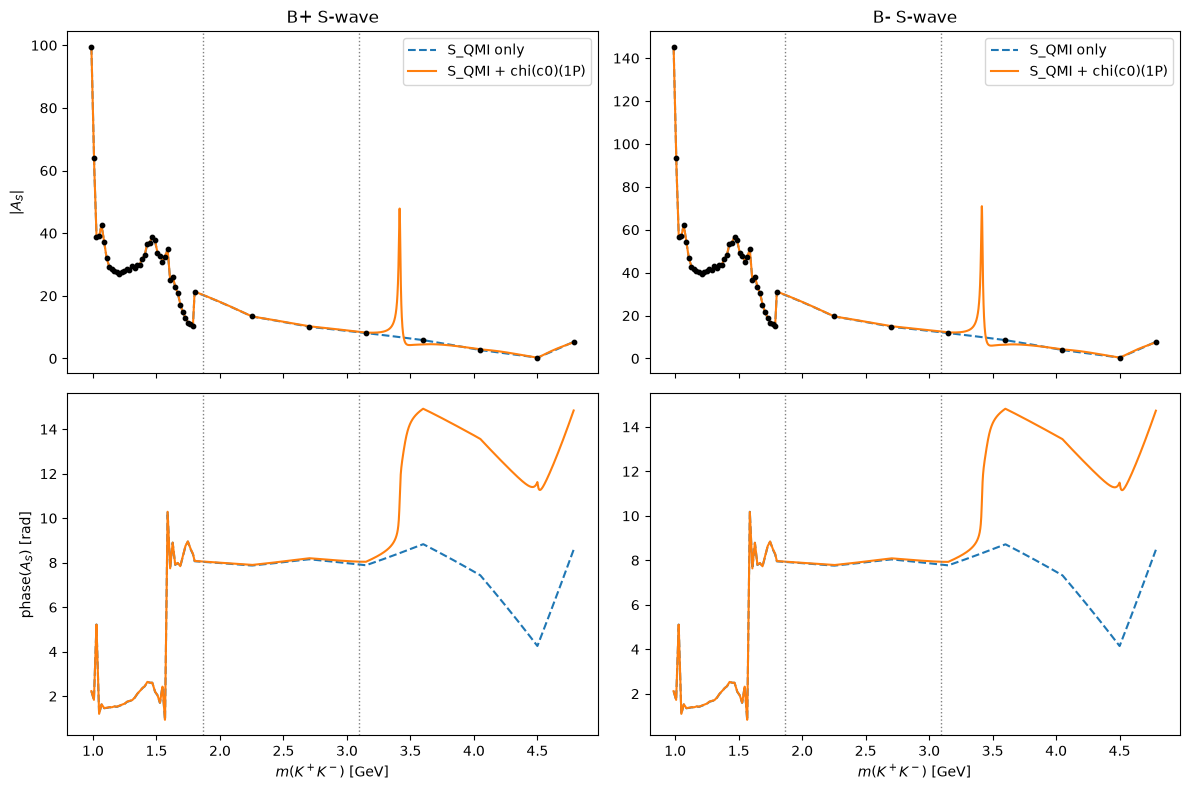

In [15]:
def component_sum_amplitude(model, names, data, values):
    """Coherent sum of the named components' AmplitudeComponent.value(...).

    Uses only the public `model.amplitude_model.components` /
    `AmplitudeComponent.value` API. Safe to skip the per-component
    normalization scale here because this notebook's models are built with
    normalize_components=False throughout (see build_models() above).
    """
    total = None
    for component in model.amplitude_model.components:
        if component.name not in names:
            continue
        contribution = component.value(data, parameters=values, coefficient_values=values)
        total = contribution if total is None else total + contribution
    return jnp.asarray(total)


def swave_scan(model, values, mass_scan, *, include_chic0):
    s = np.asarray(mass_scan, dtype=float) ** 2
    s12 = M_B_GEV**2 + 3.0 * M_K_GEV**2 - 2.0 * s
    data = {
        's12': jnp.asarray(s12),
        's13': jnp.asarray(s),
        's23': jnp.asarray(s),
    }
    names = {'S_QMI', 'chi(c0)(1P)'} if include_chic0 else {'S_QMI'}
    return np.asarray(component_sum_amplitude(model, names, data, values))


postfit_swave_values = session.result_values(result)
swave_mass_scan = np.linspace(QMI_KNOTS_GEV[0], QMI_KNOTS_GEV[-1], 4000)

swave_curves = {}
for charge_label, charge_model in (('B+', plus_model), ('B-', minus_model)):
    for include_chic0, tag in ((False, 'S_QMI only'), (True, "S_QMI + chi(c0)(1P)")):
        swave_curves[(charge_label, tag)] = swave_scan(
            charge_model, postfit_swave_values, swave_mass_scan,
            include_chic0=include_chic0,
        )

qmi_only_knot_values = {
    charge_label: swave_scan(
        charge_model, postfit_swave_values, np.asarray(QMI_KNOTS_GEV), include_chic0=False,
    )
    for charge_label, charge_model in (('B+', plus_model), ('B-', minus_model))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for col, charge_label in enumerate(('B+', 'B-')):
    for tag, style in (('S_QMI only', '--'), ("S_QMI + chi(c0)(1P)", '-')):
        amplitude = swave_curves[(charge_label, tag)]
        axes[0, col].plot(swave_mass_scan, np.abs(amplitude), style, label=tag)
        axes[1, col].plot(swave_mass_scan, np.unwrap(np.angle(amplitude)), style, label=tag)

    axes[0, col].scatter(
        QMI_KNOTS_GEV, np.abs(qmi_only_knot_values[charge_label]), s=10, color='black', zorder=3,
    )
    for mass in (D0_MASS_GEV, JPSI_MASS_GEV):
        axes[0, col].axvline(mass, color='grey', ls=':', lw=1)
        axes[1, col].axvline(mass, color='grey', ls=':', lw=1)

    axes[0, col].set_title(f'{charge_label} S-wave')
    axes[1, col].set_xlabel(r'$m(K^+K^-)$ [GeV]')
    axes[0, col].legend()

axes[0, 0].set_ylabel(r'$|A_S|$')
axes[1, 0].set_ylabel(r'phase$(A_S)$ [rad]')
fig.tight_layout()
plt.show()


### Zoom: \(m(K^+K^-)<2\) GeV (\(s<4\) GeV\(^2\))

Same postfit `S_QMI`-only and `S_QMI+chi(c0)(1P)` curves as above, restricted to
where the QMI knots are densest and the replaced isobar structure
(threshold cusp, \(f_0(1500)\), \(f_0(1710)\)) sits, matching the \(s_{low}<4\)
GeV\(^2\) zoom in "Postfit diagnostics" below.

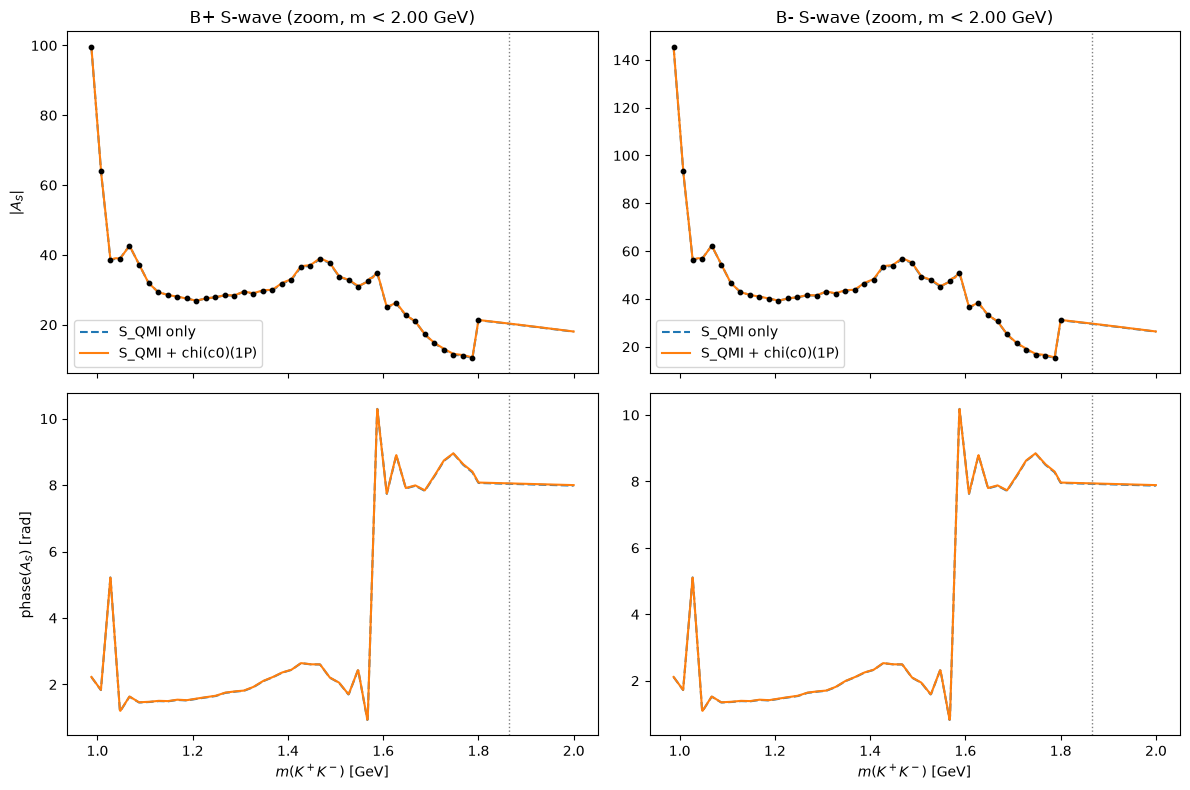

In [16]:
swave_zoom_upper_mass_gev = 2.0  # 4 GeV^2
swave_zoom_mask = swave_mass_scan <= swave_zoom_upper_mass_gev
swave_zoom_knot_mask = np.asarray(QMI_KNOTS_GEV) <= swave_zoom_upper_mass_gev

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for col, charge_label in enumerate(('B+', 'B-')):
    for tag, style in (('S_QMI only', '--'), ("S_QMI + chi(c0)(1P)", '-')):
        amplitude = swave_curves[(charge_label, tag)][swave_zoom_mask]
        axes[0, col].plot(swave_mass_scan[swave_zoom_mask], np.abs(amplitude), style, label=tag)
        axes[1, col].plot(swave_mass_scan[swave_zoom_mask], np.unwrap(np.angle(amplitude)), style, label=tag)

    axes[0, col].scatter(
        np.asarray(QMI_KNOTS_GEV)[swave_zoom_knot_mask],
        np.abs(qmi_only_knot_values[charge_label])[swave_zoom_knot_mask],
        s=10, color='black', zorder=3,
    )
    for mass in (D0_MASS_GEV, JPSI_MASS_GEV):
        if mass <= swave_zoom_upper_mass_gev:
            axes[0, col].axvline(mass, color='grey', ls=':', lw=1)
            axes[1, col].axvline(mass, color='grey', ls=':', lw=1)

    axes[0, col].set_title(f'{charge_label} S-wave (zoom, m < {swave_zoom_upper_mass_gev:.2f} GeV)')
    axes[1, col].set_xlabel(r'$m(K^+K^-)$ [GeV]')
    axes[0, col].legend()

axes[0, 0].set_ylabel(r'$|A_S|$')
axes[1, 0].set_ylabel(r'phase$(A_S)$ [rad]')
fig.tight_layout()
plt.show()


## Postfit diagnostics

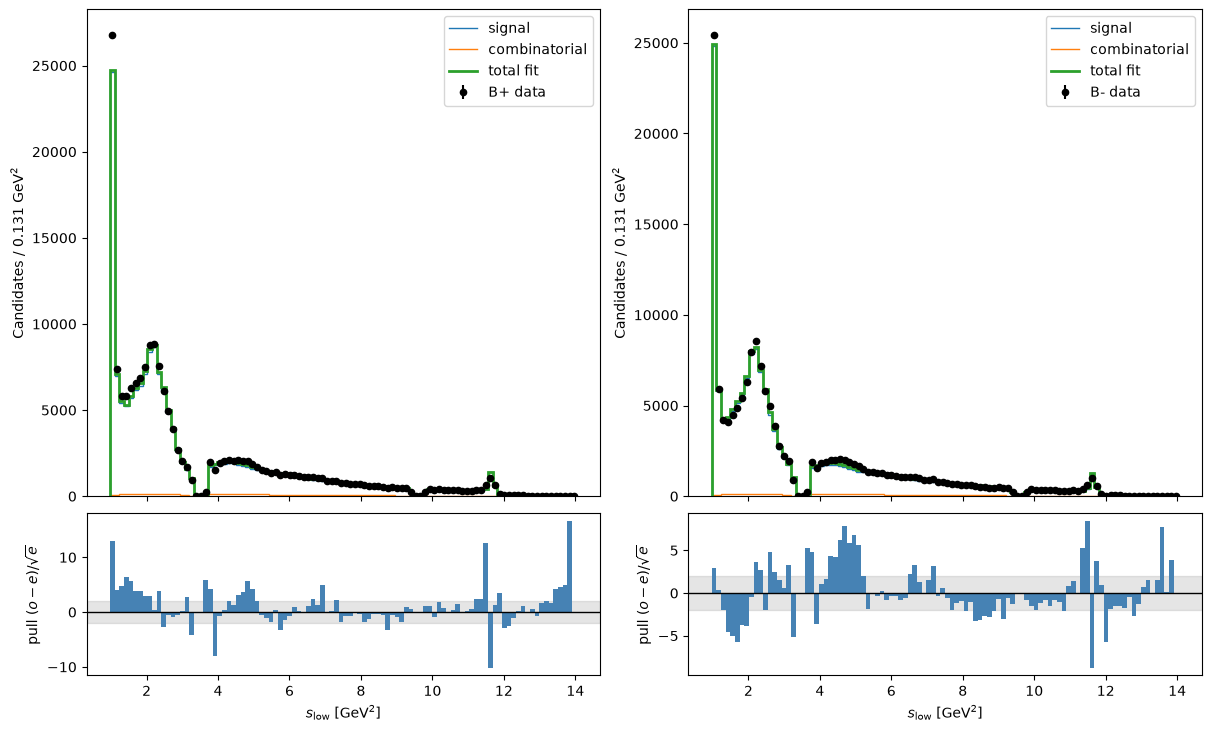

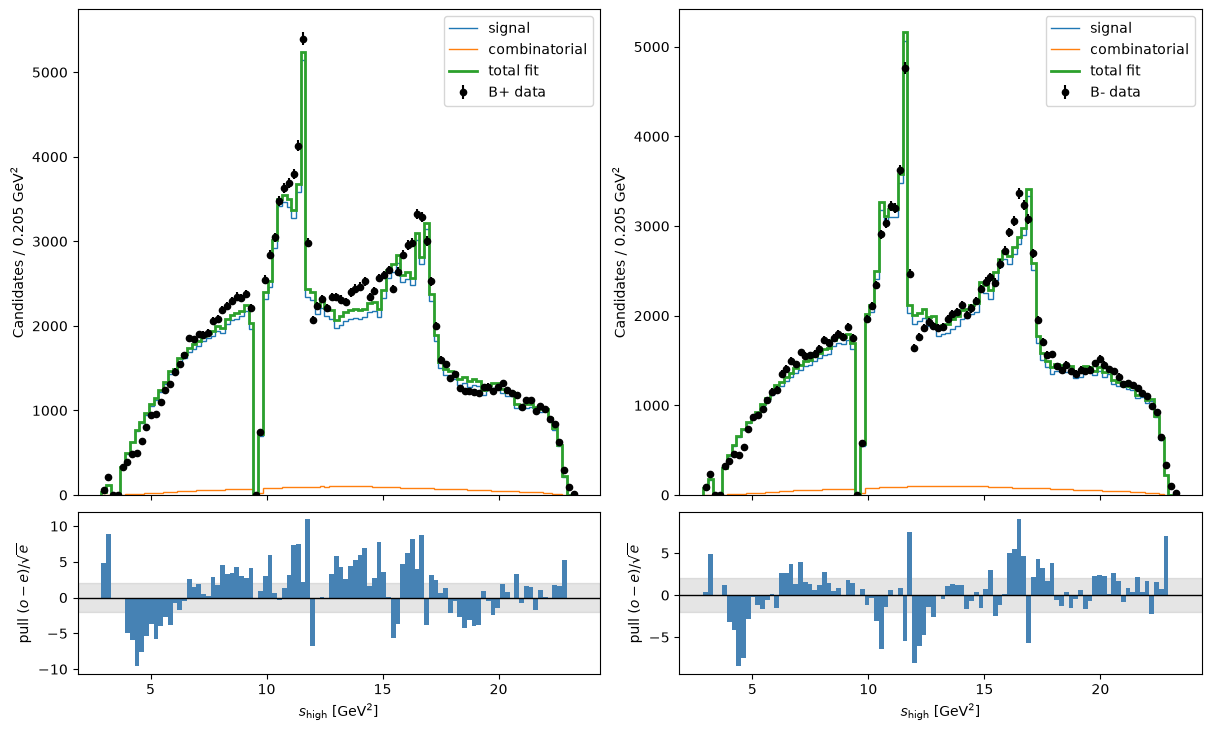

Post-fit: s_low zoom below 4 GeV^2


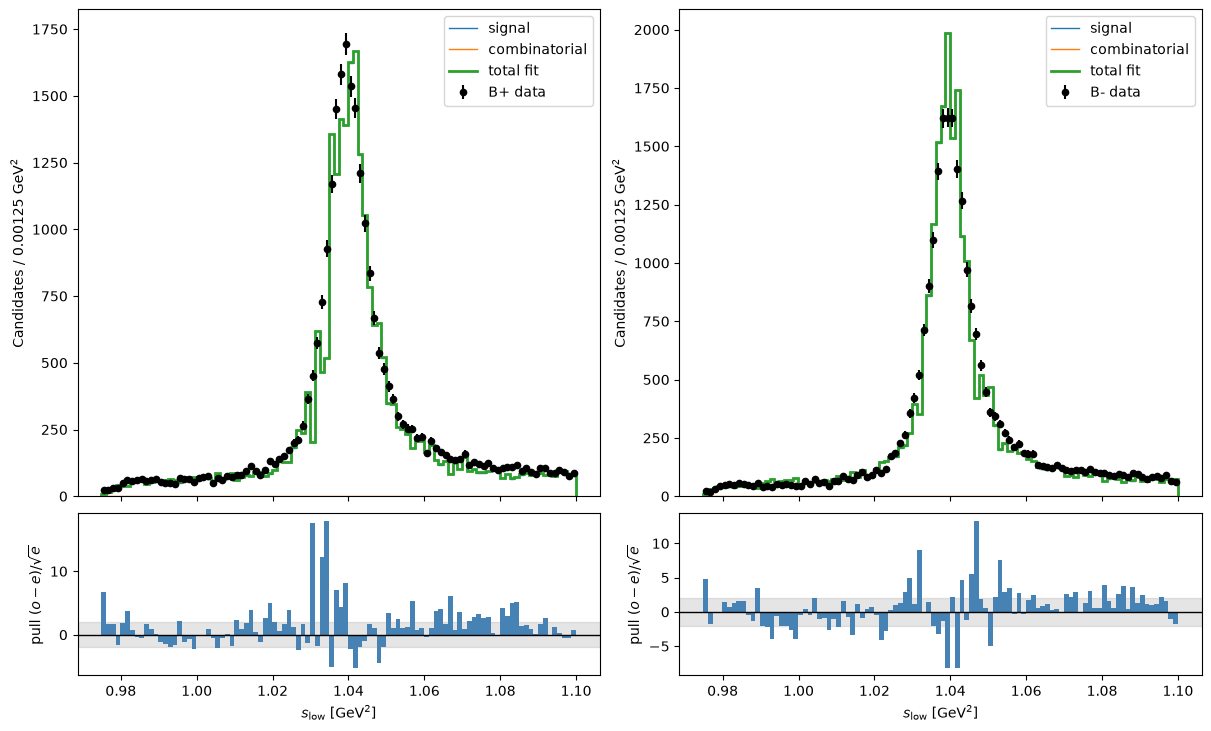

In [17]:
plot_all_diagnostics(
    result,
    title_prefix='Post-fit',
    seed=FIT_SEED + 5000,
)

## Goodness of fit

Quantitative complement to the pull panels above: the binned Pearson chi2 test
(Williams, arXiv:1006.3019, Sec. 3.1) on the folded 1D, plain Dalitz and
Square-Dalitz projections, and the unbinned point-to-point dissimilarity (PPD) test
(Williams Sec. 3.3) per charge. See `docs/goodness_of_fit.md` for the
degrees-of-freedom caveat (the amplitude parameters here come from an unbinned
fit, not from minimizing this chi2, so only a `[dof_min, dof_max]` bound on the
true p-value is available) and the `sigma_bar`/`max_total_events` tuning notes
for PPD.

PPD is `O(n^2)` in the pooled data+reference size, so it cannot run on the full
signal sample (hundreds of thousands of candidates); a dedicated reduced-data
session (`ppd_session`, same fitted models and parameters, a random subsample
of each charge's data) is built below just for that test. The chi2 tests have
no such restriction and run on the full sample, exactly like the projections
above.


Post-fit B+: 1D chi2=638.4 (n_bins=39, dof=[-87,38], p=[nan,4.56e-110])
             Dalitz chi2=4969.9 (n_bins=546, dof=[420,545], p=[0,0])
             SqDP chi2=186944.5 (n_bins=897, dof=[771,896], p=[0,0])


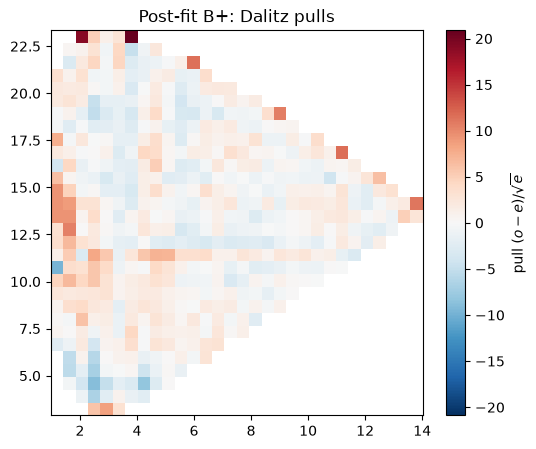

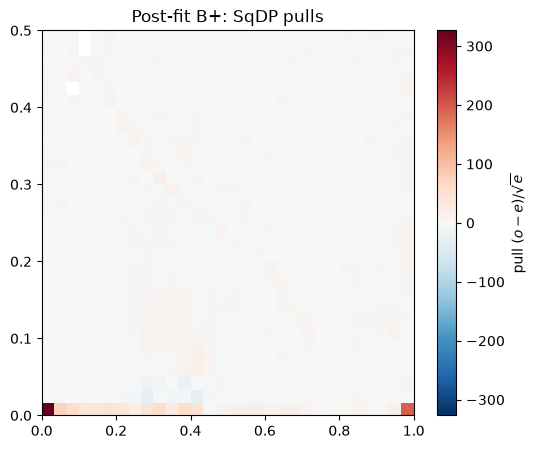

Post-fit B-: 1D chi2=590.6 (n_bins=39, dof=[-87,38], p=[nan,2.77e-100])
             Dalitz chi2=9941.4 (n_bins=549, dof=[423,548], p=[0,0])
             SqDP chi2=154211.6 (n_bins=896, dof=[770,895], p=[0,0])


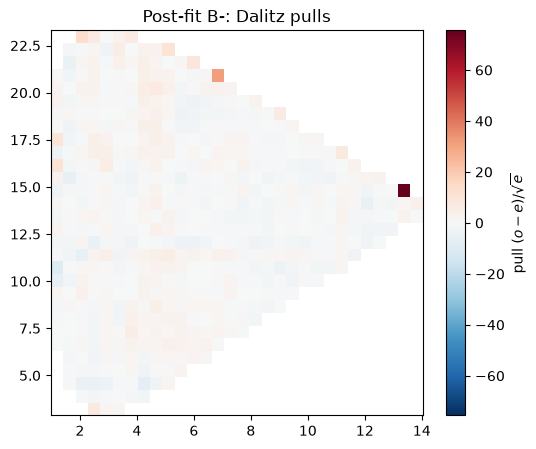

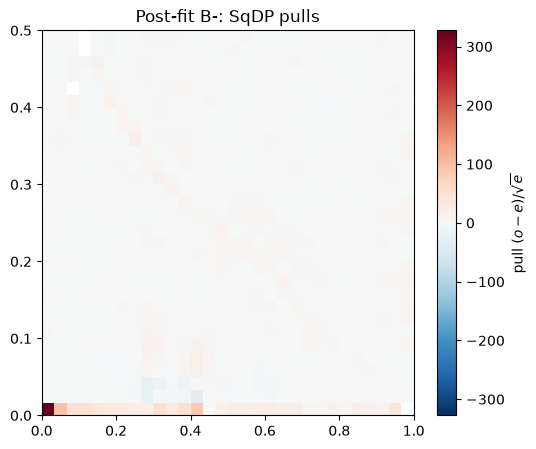

In [18]:
GOF_BINS_1D = 40
GOF_BINS_2D = (30, 30)
PPD_SAMPLE_SIZE = 2000
PPD_MC_SIZE = 3000
# Derived, not duplicated: point_to_point_dissimilarity's own O(n^2) guard
# (default max_total_events=5_000) must never silently drift out of sync
# with the sizes actually requested above.
PPD_MAX_TOTAL_EVENTS = PPD_SAMPLE_SIZE + PPD_MC_SIZE
PPD_PERMUTATIONS = 200
PPD_SEED = FIT_SEED + 7000


def goodness_of_fit_summary(
    fit_result,
    title_prefix,
    bins_1d=GOF_BINS_1D,
    bins_2d=GOF_BINS_2D,
    size=PROJECTION_SIZE,
    seed=FIT_SEED,
):
    """Binned chi2 (folded s_low/s_high 1D, folded SqDP 2D) per charge.

    Bins are chosen independently from `PROJECTION_BINS` (tuned for smooth
    visual projections, not for adequate per-bin occupancy in a chi2 test);
    reduce them if any bins come out empty for the current data/model.
    """
    gof_1d = session.goodness_of_fit_projection(
        fit_result, 's13', bins=bins_1d, folded=True, partner_variable='s23',
        projection_size=size, projection_seed=seed,
    )
    gof_dalitz = session.goodness_of_fit_chi2(
        fit_result, 's13', 's23', folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 1,
    )
    gof_sqdp = session.goodness_of_fit_chi2(
        fit_result, square_dalitz=True, mother_mass=M_B_GEV, masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR, folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 2,
    )

    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        one_d = gof_1d[charge]
        dalitz = gof_dalitz[charge]
        sqdp = gof_sqdp[charge]
        print(
            f"{label}: 1D chi2={one_d.chi2:.1f} (n_bins={one_d.n_bins}, "
            f"dof=[{one_d.dof_min},{one_d.dof_max}], "
            f"p=[{one_d.p_value_min:.3g},{one_d.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  Dalitz chi2={dalitz.chi2:.1f} (n_bins={dalitz.n_bins}, "
            f"dof=[{dalitz.dof_min},{dalitz.dof_max}], "
            f"p=[{dalitz.p_value_min:.3g},{dalitz.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  SqDP chi2={sqdp.chi2:.1f} (n_bins={sqdp.n_bins}, "
            f"dof=[{sqdp.dof_min},{sqdp.dof_max}], "
            f"p=[{sqdp.p_value_min:.3g},{sqdp.p_value_max:.3g}])"
        )

        for name, two_d in (('Dalitz', dalitz), ('SqDP', sqdp)):
            fig, ax = plt.subplots(figsize=(6, 5))
            plot_pulls(two_d, ax=ax)
            ax.set_title(f'{label}: {name} pulls')
            plt.show()


def ppd_subsample(sample, size, seed):
    """A random unweighted subsample, or the sample unchanged if already small."""
    if sample.size <= size:
        return sample
    rng = np.random.default_rng(seed)
    indices = rng.choice(sample.size, size=size, replace=False)
    return sample.take(jnp.asarray(indices))


def point_to_point_summary(
    fit_result,
    title_prefix,
    sample_size=PPD_SAMPLE_SIZE,
    mc_size=PPD_MC_SIZE,
    n_permutations=PPD_PERMUTATIONS,
    seed=PPD_SEED,
    max_total_events=PPD_MAX_TOTAL_EVENTS,
):
    ppd_session = replace(
        session,
        plus_data=ppd_subsample(samples['plus'], sample_size, seed),
        minus_data=ppd_subsample(samples['minus'], sample_size, seed + 1),
    )
    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        ppd = ppd_session.point_to_point_dissimilarity(
            fit_result, charge=charge, mc_size=mc_size,
            n_permutations=n_permutations, seed=seed + 2,
            max_total_events=max_total_events,
        )
        print(
            f"{label}: PPD statistic={ppd.statistic:.3e}, p={ppd.p_value:.3g} "
            f"(n_data={ppd.n_data} subsample, n_reference={ppd.n_reference})"
        )


goodness_of_fit_summary(result, title_prefix='Post-fit')
# point_to_point_summary(result, title_prefix='Post-fit')


## Folded background and efficiency

Background and efficiency are both built directly from the ROOT files' own
`mPrime`/`thPrime` branches — no invariants-to-square-Dalitz recomputation
or manual mirroring is used to build them.

The two identical \(K^+\) are particles \((0, 1)\) in `('K+', 'K+', 'K-')`;
`SQDP_PAIR = (0, 1)` is exactly this identical pair (verified numerically:
using it to recompute \(m'\)/\(\theta'\) from `s12`/`s13`/`s23` with the
per-candidate mass reproduces the stored ROOT `mPrime`/`thPrime` branches).
`thPrime` in the ROOT files is already folded onto `[0, 0.5]`, so the
histogram is built directly on that half-domain and handed to
`SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` with
`folded=True`, `pair=SQDP_PAIR` — evaluation (on the fit's own `s12`/`s13`/
`s23`) recomputes \(m'\)/\(\theta'\) internally and folds any query point
onto the same half, so no explicit unfolding/mirroring step is required.

The "Goodness of fit" section's `goodness_of_fit_chi2(square_dalitz=True)`
calls, unlike this background/efficiency construction, always recompute
\(m'\)/\(\theta'\) from `s12`/`s13`/`s23` for *both* data and model --
`CPFitSession` has no hook to substitute the ROOT files' own `mPrime`/
`thPrime` branches for the data side there. The two are numerically close
(see the `SQDP_PAIR` verification note above) but not identical; this is a
deliberate simplification to keep the postfit checks expressed entirely in
terms of the fitter's own public API rather than a second, hand-rolled
recomputation path.

The fit itself normalizes with `toy-mc`: a single flat 1,000,000-event
`PhaseSpaceMC` sample, generated once and passed as `normalization_sample=`
to both the B+ and B- models, so no new integration points are drawn during
minimization and both charges share identical integration noise
(`docs/mc_integration.md`).